# CALIDAD DE DETECCIÓN — MEDIAPIPE HANDLANDMARKER
## Análisis de sesgo sistemático en detección de mano por score UPDRS

MediaPipe HandLandmarker detecta landmarks de mano en cada frame.
Videos donde menos del 90% de frames tienen detección válida son
rechazados automáticamente. Este notebook analiza si la tasa de
detección varía sistemáticamente con el score UPDRS — lo que
indicaría un sesgo: pacientes más severos podrían tener peor
detección, afectando la representatividad del dataset.

---
## CELDA 1 — Imports y configuración

In [1]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
Centraliza rutas, paletas y parámetros del análisis de calidad.
============================================================================
"""

import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, spearmanr, mannwhitneyu

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar parámetros aquí
# ─────────────────────────────────────────────
class Config:
    DATASET_ID = 'fis'
    UMBRAL_RECHAZO = 90.0
    RUTA_PROCESADOS = f'../log/{DATASET_ID}_frame_rate_processed_videos.csv'
    RUTA_RECHAZADOS = f'../log/{DATASET_ID}_frame_rate_rejected_videos.csv'
    RUTA_FPS = f'../output_files/{DATASET_ID}_fps_videos.csv'
    RUTA_DIAGNOSTICO = f'../input_files/{DATASET_ID}_diagnostic.csv'
    RUTA_SALIDA = '../results_files/calidad_mediapipe/'
    SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}

os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f'{Config.RUTA_SALIDA}/figuras', exist_ok=True)
os.makedirs(f'{Config.RUTA_SALIDA}/tablas', exist_ok=True)

print('✅ Configuración cargada')
print(f'   Dataset ID : {Config.DATASET_ID}')
print(f'   Ruta salida: {Config.RUTA_SALIDA}')

✅ Configuración cargada
   Dataset ID : fis
   Ruta salida: ../results_files/calidad_mediapipe/


---
## CELDA 2 — Carga y preparación

In [2]:
"""
============================================================================
CARGA Y CONSOLIDACIÓN DE DATOS DE CALIDAD
Carga procesados/rechazados, diagnóstico y FPS en un solo dataframe.
============================================================================
"""

def _normalizar_pct(df):
    if df is None or df.empty:
        return df
    cols = list(df.columns)
    id_col = 'ID' if 'ID' in cols else cols[0]
    df = df.rename(columns={id_col: 'ID'})
    pct_cols = [c for c in df.columns if 'percent' in c.lower() or 'percentage' in c.lower() or 'pct' in c.lower()]
    if pct_cols:
        pct_col = pct_cols[0]
    elif len(df.columns) > 1:
        pct_col = [c for c in df.columns if c != 'ID'][0]
        print(f'⚠️ Columna porcentaje no explícita, se usará: {pct_col}')
    else:
        print('⚠️ No se encontró columna de porcentaje')
        return df
    df = df.rename(columns={pct_col: 'pct_validos'})
    df['pct_validos'] = (
        df['pct_validos']
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df['pct_validos'] = pd.to_numeric(df['pct_validos'], errors='coerce')
    df['ID'] = df['ID'].astype(str)
    return df

def _leer_calidad(path, estado):
    if not os.path.exists(path):
        print(f'⚠️ Archivo no encontrado: {path}')
        return pd.DataFrame(columns=['ID', 'pct_validos', 'estado'])
    df = pd.read_csv(path)
    df = _normalizar_pct(df)
    if 'pct_validos' not in df.columns:
        print(f'⚠️ No se pudo normalizar porcentaje en: {path}')
        return pd.DataFrame(columns=['ID', 'pct_validos', 'estado'])
    df['estado'] = estado
    return df[['ID', 'pct_validos', 'estado']]

df_proc = _leer_calidad(Config.RUTA_PROCESADOS, 'aceptado')
df_rej = _leer_calidad(Config.RUTA_RECHAZADOS, 'rechazado')

df_calidad = pd.concat([df_rej, df_proc], ignore_index=True)
if not df_calidad.empty:
    estado_order = {'rechazado': 0, 'aceptado': 1}
    df_calidad = df_calidad.sort_values('estado', key=lambda s: s.map(estado_order))
    df_calidad = df_calidad.drop_duplicates(subset=['ID'], keep='first')

df_diag = pd.read_csv(Config.RUTA_DIAGNOSTICO, dtype={'ID': str})
df_diag['UPDRS'] = df_diag['UPDRS'].astype(int)
df_diag = df_diag.rename(columns={'UPDRS': 'score'})

df_fps = pd.read_csv(Config.RUTA_FPS, dtype={'ID': str})
if 'FPS' not in df_fps.columns:
    fps_col = [c for c in df_fps.columns if c.lower() == 'fps']
    if fps_col:
        df_fps = df_fps.rename(columns={fps_col[0]: 'FPS'})
df_fps['FPS'] = pd.to_numeric(df_fps['FPS'], errors='coerce')

df_calidad_completo = df_calidad.merge(df_diag, on='ID', how='left')
df_calidad_completo = df_calidad_completo.merge(df_fps, on='ID', how='left')

total_proc = len(df_proc)
total_rej = len(df_rej)
total_all = total_proc + total_rej
pct_rej_global = 100 * total_rej / total_all if total_all else 0

print(f'★ Total videos procesados: {total_proc}')
print(f'★ Total videos rechazados: {total_rej} ({pct_rej_global:.1f}%)')

df_aceptados = df_calidad_completo[df_calidad_completo['estado'] == 'aceptado'].copy()
df_rechazados = df_calidad_completo[df_calidad_completo['estado'] == 'rechazado'].copy()

df_aceptados_score = df_aceptados[df_aceptados['score'].notna()]
df_rechazados_score = df_rechazados[df_rechazados['score'].notna()]

if df_aceptados_score.empty:
    print('⚠️ No hay scores disponibles para videos aceptados.')
else:
    print('★ Distribución de videos aceptados por score:')
    print(df_aceptados_score['score'].value_counts().sort_index().to_string())

if df_rechazados_score.empty and not df_rechazados.empty:
    print('⚠️ Videos rechazados sin score disponible; no se puede analizar por score.')
elif not df_rechazados_score.empty:
    print('★ Distribución de videos rechazados por score:')
    print(df_rechazados_score['score'].value_counts().sort_index().to_string())

fps_unique = df_fps['FPS'].dropna().unique()
if len(fps_unique) <= 5:
    print(f'★ FPS únicos: {sorted(fps_unique)}')
else:
    print('★ FPS distribución:')
    print(df_fps['FPS'].describe().round(2).to_string())

⚠️ Columna porcentaje no explícita, se usará: Porcentaje
★ Total videos procesados: 220
★ Total videos rechazados: 14 (6.0%)
★ Distribución de videos aceptados por score:
score
0    68
1    96
2    33
3    23
★ Distribución de videos rechazados por score:
score
0    3
1    3
2    5
3    3
★ FPS distribución:
count    234.00
mean      30.28
std        2.76
min       29.51
25%       30.02
50%       30.04
75%       30.04
max       59.96


---
## CELDA 3 — Tasa de rechazo por score

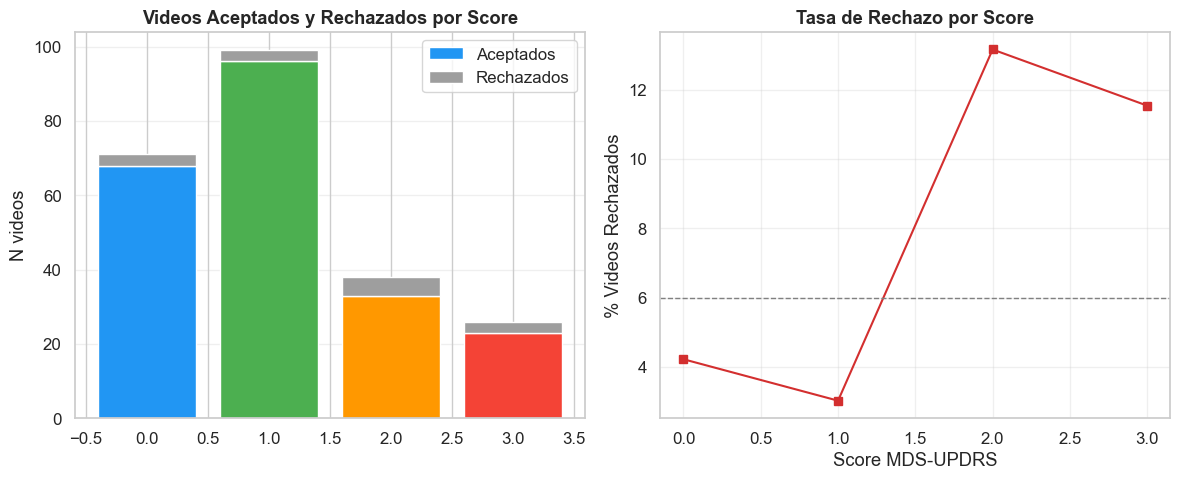

⚠️ Se observa gradiente de rechazo por score: sesgo potencial.


In [3]:
"""
============================================================================
ANÁLISIS DE RECHAZO — ¿Se rechazan más videos de ciertos scores?
Calcula rechazo por score y visualiza tendencia.
============================================================================
"""

rechazo_rho = np.nan
rechazo_p = np.nan

df_score = df_calidad_completo[df_calidad_completo['score'].notna()].copy()
if df_score.empty:
    print('⚠️ No hay scores disponibles para análisis de rechazo por score.')
    df_rechazo = pd.DataFrame()
else:
    df_counts = df_score.groupby(['score', 'estado']).size().unstack(fill_value=0)
    if 'aceptado' not in df_counts.columns:
        df_counts['aceptado'] = 0
    if 'rechazado' not in df_counts.columns:
        df_counts['rechazado'] = 0
    df_counts['total'] = df_counts['aceptado'] + df_counts['rechazado']
    df_counts['pct_rechazo'] = 100 * df_counts['rechazado'] / df_counts['total'].replace(0, np.nan)
    df_rechazo = df_counts.reset_index().sort_values('score')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax1, ax2 = axes

    scores = df_rechazo['score'].tolist()
    aceptados = df_rechazo['aceptado'].values
    rechazados = df_rechazo['rechazado'].values
    colors = [Config.SCORE_COLORS.get(s, '#90CAF9') for s in scores]

    ax1.bar(scores, aceptados, color=colors, label='Aceptados')
    ax1.bar(scores, rechazados, bottom=aceptados, color='#9E9E9E', label='Rechazados')
    ax1.set_ylabel('N videos')
    ax1.set_title('Videos Aceptados y Rechazados por Score', fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    ax2.plot(scores, df_rechazo['pct_rechazo'], marker='s', color='#D32F2F')
    ax2.axhline(pct_rej_global, linestyle='--', color='gray', linewidth=1)
    ax2.set_ylabel('% Videos Rechazados')
    ax2.set_xlabel('Score MDS-UPDRS')
    ax2.set_title('Tasa de Rechazo por Score', fontweight='bold')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(f'{Config.RUTA_SALIDA}/figuras/tasa_rechazo_por_score.png', dpi=150, bbox_inches='tight')
    plt.show()

    if len(scores) >= 2:
        rechazo_rho, rechazo_p = spearmanr(scores, df_rechazo['pct_rechazo'])
    gradiente = (df_rechazo['pct_rechazo'].max() - df_rechazo['pct_rechazo'].min()) if not df_rechazo.empty else 0
    if gradiente > 10 or (not np.isnan(rechazo_rho) and rechazo_rho > 0.3 and rechazo_p < 0.05):
        print('⚠️ Se observa gradiente de rechazo por score: sesgo potencial.')
    else:
        print('✓ Distribución de rechazo relativamente uniforme por score.')

---
## CELDA 4 — Distribución de % detección

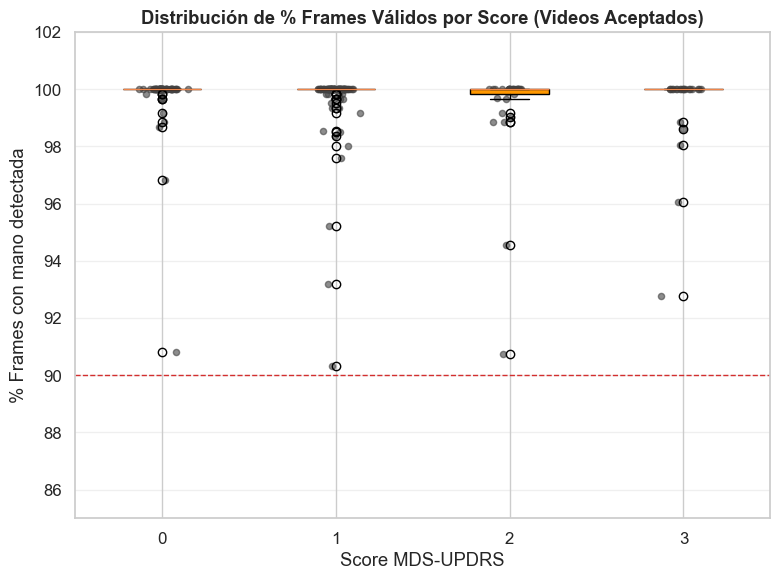

★ Kruskal-Wallis: H=4.147, p=0.2461, η²=0.005
★ Spearman: ρ=-0.127, p=0.0596
✓ Detección uniforme entre scores (sin sesgo significativo).


In [4]:
"""
============================================================================
DISTRIBUCIÓN DE % FRAMES VÁLIDOS — Solo videos aceptados
Evalúa sesgo en la tasa de detección por score.
============================================================================
"""

rho_deteccion = np.nan
p_deteccion = np.nan
kw_deteccion_p = np.nan

df_acc = df_aceptados_score.copy()
if df_acc.empty:
    print('⚠️ No hay videos aceptados con score para análisis de detección.')
else:
    grouped = df_acc.groupby('score')['pct_validos']
    scores = sorted(grouped.groups.keys())
    data = [grouped.get_group(s).dropna().values for s in scores]

    fig, ax = plt.subplots(figsize=(8, 6))
    box = ax.boxplot(data, labels=scores, patch_artist=True)
    for patch, s in zip(box['boxes'], scores):
        patch.set_facecolor(Config.SCORE_COLORS.get(s, '#90CAF9'))
    for i, s in enumerate(scores):
        y_vals = grouped.get_group(s).values
        x_vals = np.random.normal(i + 1, 0.05, size=len(y_vals))
        ax.scatter(x_vals, y_vals, color='#424242', alpha=0.6, s=20)
    ax.axhline(Config.UMBRAL_RECHAZO, linestyle='--', color='#D32F2F', linewidth=1)
    ax.set_ylim([85, 102])
    ax.set_title('Distribución de % Frames Válidos por Score (Videos Aceptados)', fontweight='bold')
    ax.set_ylabel('% Frames con mano detectada')
    ax.set_xlabel('Score MDS-UPDRS')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(f'{Config.RUTA_SALIDA}/figuras/deteccion_por_score.png', dpi=150, bbox_inches='tight')
    plt.show()

    if len(data) >= 2:
        H, kw_deteccion_p = kruskal(*data)
        n = len(df_acc)
        k = len(data)
        eta2 = (H - k + 1) / (n - k) if n > k else np.nan
        print(f'★ Kruskal-Wallis: H={H:.3f}, p={kw_deteccion_p:.4f}, η²={eta2:.3f}')
    else:
        print('⚠️ No hay suficientes grupos para Kruskal-Wallis.')

    rho_deteccion, p_deteccion = spearmanr(df_acc['score'], df_acc['pct_validos'])
    print(f'★ Spearman: ρ={rho_deteccion:.3f}, p={p_deteccion:.4f}')
    if abs(rho_deteccion) > 0.2 and p_deteccion < 0.05:
        print('⚠️ Correlación significativa: posible sesgo en detección.')
    else:
        print('✓ Detección uniforme entre scores (sin sesgo significativo).')

---
## CELDA 5 — Análisis de FPS

★ FPS media=30.28, std=2.76, min=29.51, max=59.96, moda=30.04
★ Kruskal-Wallis FPS: H=3.907, p=0.2717


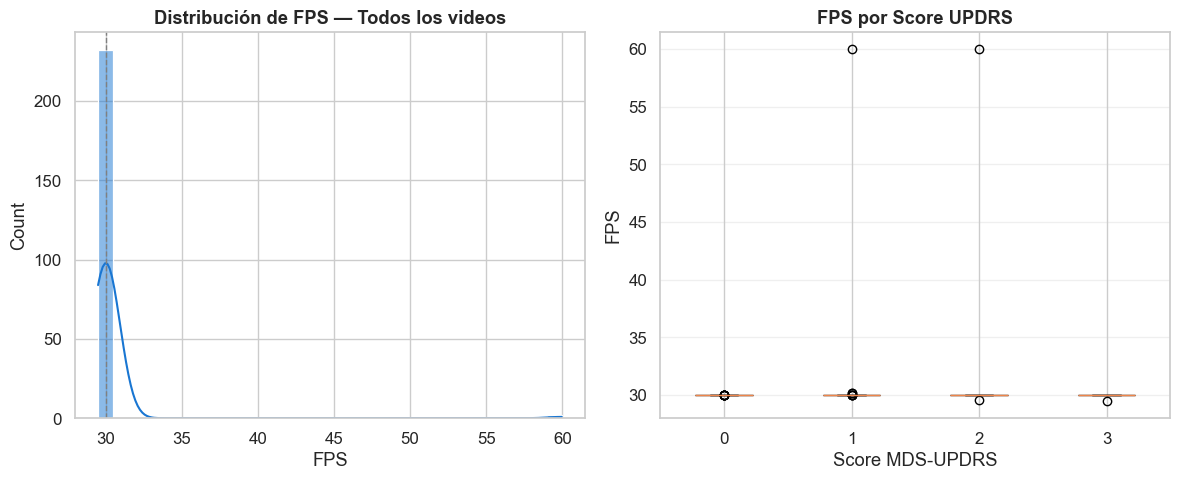

Nota: Las features de tiempo (ITI_MEAN, ITI_STD, FREQUENCY_mean) se calculan usando el FPS real.
Si FPS varía entre grupos, las features son comparables solo si la normalización por FPS se aplicó correctamente en extract_features.py.


In [5]:
"""
============================================================================
ANÁLISIS DE FPS — Variabilidad entre videos
============================================================================
"""

kw_fps_p = np.nan
df_fps_merge = df_calidad_completo[['ID', 'score', 'FPS']].copy()
fps_vals = df_fps_merge['FPS'].dropna()

if fps_vals.empty:
    print('⚠️ No hay datos de FPS para análisis.')
    df_fps_stats = pd.DataFrame()
else:
    fps_mode = fps_vals.mode().iloc[0] if not fps_vals.mode().empty else np.nan
    print(f'★ FPS media={fps_vals.mean():.2f}, std={fps_vals.std():.2f}, min={fps_vals.min():.2f}, max={fps_vals.max():.2f}, moda={fps_mode:.2f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax1, ax2 = axes

    sns.histplot(fps_vals, kde=True, ax=ax1, color='#1976D2')
    if not np.isnan(fps_mode):
        ax1.axvline(fps_mode, linestyle='--', color='gray', linewidth=1)
    ax1.set_xlabel('FPS')
    ax1.set_title('Distribución de FPS — Todos los videos', fontweight='bold')

    df_fps_score = df_fps_merge[df_fps_merge['score'].notna()]
    grouped = df_fps_score.groupby('score')['FPS']
    scores = sorted(grouped.groups.keys())
    data = [grouped.get_group(s).dropna().values for s in scores]
    if data:
        box = ax2.boxplot(data, labels=scores, patch_artist=True)
        for patch, s in zip(box['boxes'], scores):
            patch.set_facecolor(Config.SCORE_COLORS.get(s, '#90CAF9'))
        ax2.set_title('FPS por Score UPDRS', fontweight='bold')
        ax2.set_xlabel('Score MDS-UPDRS')
        ax2.set_ylabel('FPS')
        ax2.grid(axis='y', alpha=0.3)

        if len(data) >= 2:
            H_fps, kw_fps_p = kruskal(*data)
            print(f'★ Kruskal-Wallis FPS: H={H_fps:.3f}, p={kw_fps_p:.4f}')
        else:
            print('⚠️ No hay suficientes grupos para Kruskal-Wallis en FPS.')
    else:
        print('⚠️ No hay FPS con score para boxplot.')

    plt.tight_layout()
    fig.savefig(f'{Config.RUTA_SALIDA}/figuras/fps_por_score.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Nota: Las features de tiempo (ITI_MEAN, ITI_STD, FREQUENCY_mean) se calculan usando el FPS real.')
    print('Si FPS varía entre grupos, las features son comparables solo si la normalización por FPS se aplicó correctamente en extract_features.py.')

    df_fps_stats = df_fps_score.groupby('score')['FPS'].agg(['mean', 'std', 'min', 'max', 'count']).reset_index()
    df_fps_stats['mode'] = df_fps_score.groupby('score')['FPS'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan).values

---
## CELDA 6 — Impacto en el dataset

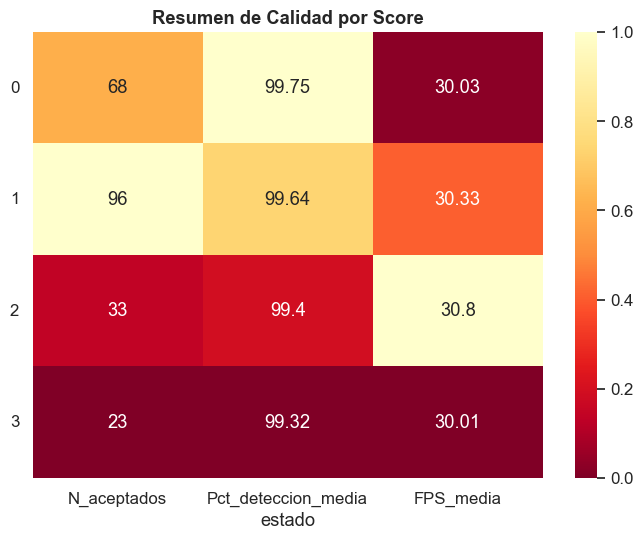

✓ La distribución de videos aceptados no muestra sesgo sistemático significativo por score.


In [6]:
"""
============================================================================
IMPACTO EN EL DATASET — ¿Qué scores quedaron sub-representados?
Construye tabla resumen y heatmap de métricas por score.
============================================================================
"""

df_score_all = df_calidad_completo[df_calidad_completo['score'].notna()].copy()
if df_score_all.empty:
    print('⚠️ No hay datos suficientes para impacto por score.')
    df_impacto = pd.DataFrame()
else:
    counts = df_score_all.groupby(['score', 'estado']).size().unstack(fill_value=0)
    counts['N_filmados'] = counts.sum(axis=1)
    counts['N_aceptados'] = counts.get('aceptado', 0)
    counts['N_rechazados'] = counts.get('rechazado', 0)
    counts['Pct_rechazo'] = 100 * counts['N_rechazados'] / counts['N_filmados'].replace(0, np.nan)

    det_media = df_aceptados_score.groupby('score')['pct_validos'].mean()
    fps_media = df_score_all.groupby('score')['FPS'].mean()

    df_impacto = counts.reset_index()[['score', 'N_filmados', 'N_aceptados', 'N_rechazados', 'Pct_rechazo']]
    df_impacto = df_impacto.rename(columns={'score': 'Score'})
    df_impacto['Pct_deteccion_media'] = df_impacto['Score'].map(det_media)
    df_impacto['FPS_media'] = df_impacto['Score'].map(fps_media)

    metricas = df_impacto[['N_aceptados', 'Pct_deteccion_media', 'FPS_media']].copy()
    norm = metricas.apply(lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else 0)
    annot = metricas.round(2).astype(str).values

    fig, ax = plt.subplots(figsize=(7, 4 + 0.4 * len(df_impacto)))
    sns.heatmap(norm, annot=annot, fmt='', cmap='YlOrRd_r', ax=ax, cbar=True)
    ax.set_yticklabels(df_impacto['Score'].astype(int).tolist(), rotation=0)
    ax.set_title('Resumen de Calidad por Score', fontweight='bold')
    plt.tight_layout()
    fig.savefig(f'{Config.RUTA_SALIDA}/figuras/impacto_dataset.png', dpi=150, bbox_inches='tight')
    plt.show()

    high_rej = df_impacto[df_impacto['Pct_rechazo'] > 20]
    if not high_rej.empty:
        score_max = int(high_rej.sort_values('Pct_rechazo', ascending=False).iloc[0]['Score'])
        pct_max = high_rej['Pct_rechazo'].max()
        print(f'⚠️ Score {score_max} tiene tasa de rechazo alta ({pct_max:.1f}%). Esto puede sub-representar ese nivel de severidad.')
    else:
        print('✓ La distribución de videos aceptados no muestra sesgo sistemático significativo por score.')

---
## CELDA 7 — Exportación final

In [7]:
"""
============================================================================
EXPORTACIÓN FINAL
============================================================================
"""

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f'{Config.RUTA_SALIDA}/tablas/calidad_mediapipe_{timestamp}.xlsx'

df_videos_aceptados = df_aceptados[['ID', 'pct_validos', 'score', 'FPS']].copy() if not df_aceptados.empty else pd.DataFrame()
df_videos_rechazados = df_rechazados[['ID', 'pct_validos', 'score', 'FPS']].copy() if not df_rechazados.empty else pd.DataFrame()

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    if not df_impacto.empty:
        df_impacto.to_excel(writer, sheet_name='resumen_por_score', index=False)
    df_videos_aceptados.to_excel(writer, sheet_name='videos_aceptados', index=False)
    df_videos_rechazados.to_excel(writer, sheet_name='videos_rechazados', index=False)
    if 'df_fps_stats' in globals() and not df_fps_stats.empty:
        df_fps_stats.to_excel(writer, sheet_name='fps_estadisticos', index=False)

print(f'💾 Análisis calidad MediaPipe exportado: {excel_path}')

total_filmados = len(df_calidad_completo)
total_aceptados = len(df_aceptados)
total_rechazados = len(df_rechazados)
tasa_global = 100 * total_rechazados / total_filmados if total_filmados else 0

print(f'Total videos filmados: {total_filmados}')
print(f'Total aceptados: {total_aceptados}')
print(f'Total rechazados: {total_rechazados}')
print(f'Tasa global de rechazo: {tasa_global:.1f}%')

sesgo_rechazo = 'sí' if (not np.isnan(rechazo_p) and rechazo_p < 0.05) else 'no'
sesgo_det = 'sí' if (not np.isnan(p_deteccion) and p_deteccion < 0.05) else 'no'
sesgo_fps = 'sí' if (not np.isnan(kw_fps_p) and kw_fps_p < 0.05) else 'no'
fps_uniforme = 'no' if sesgo_fps == 'sí' else 'sí'

print(f'¿Sesgo de rechazo por score?: {sesgo_rechazo} (p={rechazo_p:.4f})')
print(f'¿Correlación detección vs score?: {sesgo_det} (rho={rho_deteccion:.3f}, p={p_deteccion:.4f})')
print(f'¿FPS uniforme entre scores?: {fps_uniforme} (p={kw_fps_p:.4f})')

if not df_impacto.empty:
    score_max = int(df_impacto.sort_values('Pct_rechazo', ascending=False).iloc[0]['Score'])
    print(f'Score con mayor tasa de rechazo: {score_max}')

if sesgo_rechazo == 'sí' or sesgo_det == 'sí' or sesgo_fps == 'sí':
    print('⚠️ Recomendación: reportar sesgo potencial como limitación del estudio.')
else:
    print('✓ No se detecta sesgo sistemático fuerte; aún así, mencionar en limitaciones.')

💾 Análisis calidad MediaPipe exportado: ../results_files/calidad_mediapipe//tablas/calidad_mediapipe_20260510_192255.xlsx
Total videos filmados: 234
Total aceptados: 220
Total rechazados: 14
Tasa global de rechazo: 6.0%
¿Sesgo de rechazo por score?: no (p=0.4000)
¿Correlación detección vs score?: no (rho=-0.127, p=0.0596)
¿FPS uniforme entre scores?: sí (p=0.2717)
Score con mayor tasa de rechazo: 2
✓ No se detecta sesgo sistemático fuerte; aún así, mencionar en limitaciones.
